### 1. Setup

In [26]:
import torchxrayvision as xrv
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchvision.utils import save_image
from pathlib import Path
from dataclasses import asdict
import sys
import os
import json
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

from preprocessing import Preprocessing
from cvae_cnn import CVAE
from counterfactual_evaluation import (
    fid_metric_calculation,
    ssim_metric_calculation,
    save_cvae_change_heatmap_sweep,
    EvaluationResult,
    write_metrics_json,
)

### 2. Hyperparameters

In [2]:
img_channels = 2
img_size = 128
latent_dim = 64
base_channels = 32
dropout = 0.05
num_classes = 2
metadata_dim = 2
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
add_lung_mask_channel = True
segmentation_device = device

verbose = True
method = 'standard'

lr=3e-4
epochs = 300
batch_size = 16
beta = 0.005
lambda_lung = 0.2
lambda_outside = 5 - 10 * lambda_lung
early_stopping_patience = 15
early_stopping_min_delta = 5e-4
early_stopping_warmup = 10
early_stopping_smoothing = 5
checkpoint_dir = "../training-results/cvae/models"


Using device: cuda


### 3. Load Dataset

In [3]:
# preprocessing = Preprocessing(label="Pneumonia")

In [ ]:
# # Create CVAE-compatible dataset
# train_dataset, test_dataset, val_dataset = preprocessing.create_cvae_dataset(
#     img_size=(img_size, img_size),
#     verbose=verbose, 
#     method=method,
#     add_lung_mask_channel=add_lung_mask_channel,
#     segmentation_device=segmentation_device
# )

Creating CVAE dataset...
Loading images...
Pneumonia patient records:
Number of duplicated rows: 0
Removed 1 outliers based on Patient Age.
New shape of dataframe: (1430, 11)
Age normalized using standardization. Mean: 44.67, Std: 17.64
Healthy patient records:
Number of duplicated rows: 0
Removed 8 outliers based on Patient Age.
New shape of dataframe: (60353, 11)
Age normalized using Min-Max scaling. Range: [1, 95] -> [0, 1]
Total unique patients: 25050

--- Split Statistics (Patient-Level) ---
Seed: 42 (for reproducibility)

TRAIN set:
  Patients: 17535
  Total images: 43450
  Pneumonia: 225 images
  Healthy: 42436 images
  Ratio: 70.3%

VAL set:
  Patients: 3757
  Total images: 9157
  Pneumonia: 54 images
  Healthy: 8939 images
  Ratio: 14.8%

TEST set:
  Patients: 3758
  Total images: 9176
  Pneumonia: 43 images
  Healthy: 8978 images
  Ratio: 14.9%
Loaded 43450 images.
Loaded 9157 images.
Loaded 9176 images.
Running TorchXRayVision lung segmentation...
Created 250/43450 lung mask

In [ ]:
# DATA_CACHE_DIR = project_root / "data" / "processed"
# DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# torch.save(train_dataset, DATA_CACHE_DIR / "train_dataset.pt")
# torch.save(val_dataset,   DATA_CACHE_DIR / "val_dataset.pt")
# torch.save(test_dataset,  DATA_CACHE_DIR / "test_dataset.pt")

# print(f"Datasets salvos em {DATA_CACHE_DIR}")

Datasets salvos em E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\data\processed


In [4]:
# Load datasets from cache:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt", weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

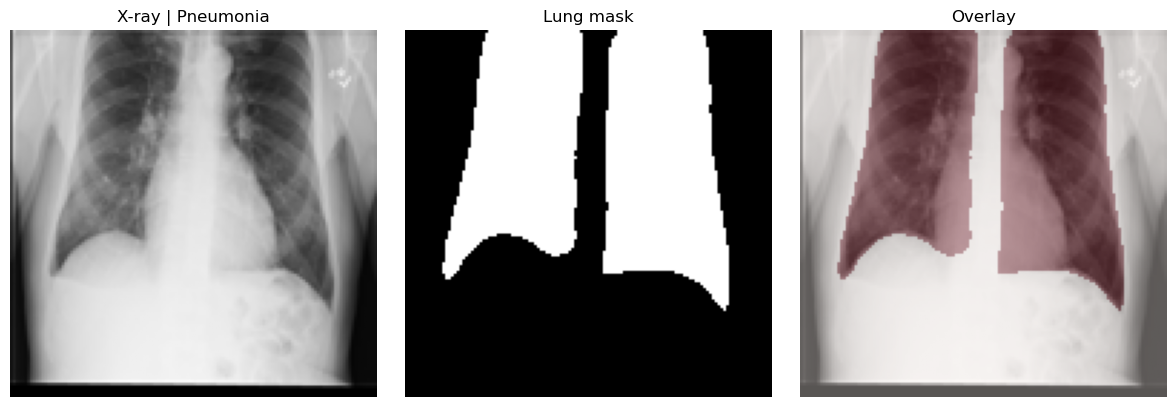

In [5]:
# Visualize one X-ray and its lung mask
sample_idx = 1
x, y, metadata = train_dataset[sample_idx]

xray = x[0].detach().cpu().numpy()
mask = x[1].detach().cpu().numpy() if x.shape[0] > 1 else None
label_name = ['Healthy', 'Pneumonia'][int(y.argmax().item())]

if mask is None:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(xray, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'X-ray | {label_name}')
    ax.axis('off')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(xray, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'X-ray | {label_name}')

    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Lung mask')

    axes[2].imshow(xray, cmap='gray', vmin=0, vmax=1)
    axes[2].imshow(mask, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
    axes[2].set_title('Overlay')

    for ax in axes:
        ax.axis('off')

plt.tight_layout()


In [ ]:
def undersample_healthy(dataset, healthy_to_pneumonia_ratio=1.0, seed=42):
    """Undersample the healthy class to balance the dataset."""
    labels = dataset.labels

    # Labels are one-hot: [1, 0] = healthy, [0, 1] = pneumonia
    class_idx = labels.argmax(dim=1)

    healthy_idx = torch.where(class_idx == 0)[0]
    pneumonia_idx = torch.where(class_idx == 1)[0]

    n_pneumonia = len(pneumonia_idx)
    n_healthy_keep = int(healthy_to_pneumonia_ratio * n_pneumonia)
    n_healthy_keep = min(n_healthy_keep, len(healthy_idx))

    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(healthy_idx), generator=generator)
    healthy_sampled_idx = healthy_idx[perm[:n_healthy_keep]]

    selected_idx = torch.cat([pneumonia_idx, healthy_sampled_idx])

    # Shuffle final selected set
    selected_idx = selected_idx[torch.randperm(len(selected_idx), generator=generator)]

    print(f"Pneumonia kept: {len(pneumonia_idx)}")
    print(f"Healthy kept: {len(healthy_sampled_idx)}")
    print(f"Final train size: {len(selected_idx)}")

    return Subset(dataset, selected_idx.tolist())

In [7]:
balanced_train_dataset = undersample_healthy(
    train_dataset,
    healthy_to_pneumonia_ratio=10.0,  # 1.0 means 1 healthy per 1 pneumonia
    seed=42
)

train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Pneumonia kept: 1014
Healthy kept: 10140
Final train size: 11154


### 4. Model, Loss, Optimizer

In [8]:
# def split_image_and_mask(x):
#     x_img = x[:, 0:1, :, :]
#     x_mask = x[:, 1:2, :, :].clamp(0, 1) if x.size(1) > 1 else None
#     return x_img, x_mask

# def mixed_reconstruction_loss(pred, target, weight=None):
#     loss_map = 0.5 * F.mse_loss(pred, target, reduction='none') + 0.5 * F.l1_loss(pred, target, reduction='none')
#     if weight is None:
#         return loss_map.mean()
#     return (loss_map * weight).sum() / weight.sum().clamp_min(1.0)

# def vae_loss(x, x_hat, mu, logvar, beta=1.0, lambda_lung=1.0, lambda_outside=2.0):
#     x_img, x_mask = split_image_and_mask(x)
#     reconstruction_loss = mixed_reconstruction_loss(x_hat, x_img)

#     if x_mask is None:
#         lung_loss = torch.zeros((), device=x.device)
#         outside_loss = torch.zeros((), device=x.device)
#     else:
#         lung_loss = mixed_reconstruction_loss(x_hat, x_img, x_mask)
#         outside_loss = mixed_reconstruction_loss(x_hat, x_img, 1.0 - x_mask)

#     # Normalize KLD by the batch size so it is on the same scale as the reconstruction loss.
#     KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     KLD = KLD / x.size(0)
#     total_loss = reconstruction_loss + lambda_lung * lung_loss + lambda_outside * outside_loss + beta * KLD
#     return total_loss, reconstruction_loss, lung_loss, outside_loss, KLD


In [ ]:
def split_image_and_mask(x):
    x_img = x[:, 0:1, :, :]
    x_mask = x[:, 1:2, :, :].clamp(0, 1) if x.size(1) > 1 else None
    return x_img, x_mask

def reconstruction_loss(x, x_hat):
    mse = F.mse_loss(x_hat, x)
    l1 = F.l1_loss(x_hat, x)
    return 0.5 * mse + 0.5 * l1

# def masked_reconstruction_loss(x, x_hat, mask=None):
#     loss_map = 0.5 * F.mse_loss(x_hat, x, reduction='none') + 0.5 * F.l1_loss(x_hat, x, reduction='none')
#     if mask is None:
#         return loss_map.mean()
#     return (loss_map * mask).sum() / mask.sum().clamp_min(1.0)

def masked_l1_loss(x, y, mask):
    return (torch.abs(x - y) * mask).sum() / mask.sum().clamp_min(1.0)


def masked_ssim_loss(x, y, mask, window_size=7):
    padding = window_size // 2
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    mu_x = F.avg_pool2d(x, window_size, stride=1, padding=padding)
    mu_y = F.avg_pool2d(y, window_size, stride=1, padding=padding)
    sigma_x = F.avg_pool2d(x * x, window_size, stride=1, padding=padding) - mu_x.pow(2)
    sigma_y = F.avg_pool2d(y * y, window_size, stride=1, padding=padding) - mu_y.pow(2)
    sigma_xy = F.avg_pool2d(x * y, window_size, stride=1, padding=padding) - mu_x * mu_y

    ssim_map = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / (
        (mu_x.pow(2) + mu_y.pow(2) + c1) * (sigma_x + sigma_y + c2)
    )
    loss_map = (1.0 - ssim_map).clamp(0, 2)
    return (loss_map * mask).sum() / mask.sum().clamp_min(1.0)


def masked_reconstruction_loss(x, y, mask, ssim_weight=0.5):
    l1 = masked_l1_loss(x, y, mask)
    ssim = masked_ssim_loss(x, y, mask)
    return (1.0 - ssim_weight) * l1 + ssim_weight * ssim

def lung_loss(x, x_hat, lung_mask):
    mse = F.mse_loss(
        x_hat * lung_mask,
        x * lung_mask
    )

    l1 = F.l1_loss(
        x_hat * lung_mask,
        x * lung_mask
    )

    return 0.5 * mse + 0.5 * l1

def outside_change_loss(x, x_hat, lung_mask):

    outside_mask = 1.0 - lung_mask

    change = torch.abs(x_hat - x)

    return (change * outside_mask).sum() / outside_mask.sum().clamp_min(1.0)

def kl_loss(mu, logvar):

    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    return kl.sum(dim=1).mean()

def validation_image_score(x, x_hat):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask
    inside_ssim = 1.0 - masked_ssim_loss(x_img, x_hat, x_mask)
    outside_ssim = 1.0 - masked_ssim_loss(x_img, x_hat, outside_mask)
    return 0.5 * inside_ssim + 0.5 * outside_ssim

def cvae_loss(x,
    x_hat,
    mu,
    logvar,
    beta=1.0,
    lambda_lung=2.0,
    lambda_outside=0.5
):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask if x_mask is not None else None
    rec = reconstruction_loss(x_img, x_hat)

    lung = masked_reconstruction_loss(x_img, x_hat, x_mask) if x_mask is not None else torch.zeros((), device=x.device)

    outside = masked_reconstruction_loss(x_img, x_hat, outside_mask) if outside_mask is not None else torch.zeros((), device=x.device)

    kl = kl_loss(mu, logvar)

    total_loss = (rec + lambda_lung * lung + lambda_outside * outside + beta * kl)

    return total_loss, rec, lung, outside, kl

In [10]:
model = CVAE(
    img_channels=img_channels,
    img_size=img_size,
    latent_dim=latent_dim,
    num_classes=num_classes,
    metadata_dim=metadata_dim,  # age + gender
    output_channels=1,
    base_channels=base_channels,
    dropout=dropout
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=lr)

### 5. Training

In [11]:
def evaluate(model, evaluate_loader, device, epoch, beta=1.0, lambda_lung=1.0, lambda_outside=2.0, results_dir="../training-results/cvae/results"):
    model.eval()
    total_loss = 0
    total_rec_loss = 0
    total_lung_loss = 0
    total_outside_loss = 0
    total_kld = 0
    total_image_score = 0
    with torch.no_grad():
        for i, batch in enumerate(evaluate_loader):
            x, y, m = batch
            x = x.to(device)
            y = y.to(device)
            m = m.to(device) if m is not None else None
            
            x_img, _ = split_image_and_mask(x)
            x_hat, mu, logvar = model(x, y, m)
            loss, rec_loss, lung_loss, outside_loss, kld = cvae_loss(
                x, x_hat, mu, logvar,
                beta=beta,
                lambda_lung=lambda_lung,
                lambda_outside=lambda_outside,
            )
            image_score = validation_image_score(x, x_hat)
            total_loss += loss.item() * x.size(0)
            total_rec_loss += rec_loss.item() * x.size(0)
            total_lung_loss += lung_loss.item() * x.size(0)
            total_outside_loss += outside_loss.item() * x.size(0)
            total_kld += kld.item() * x.size(0)
            total_image_score += image_score.item() * x.size(0)

            if i == 0:
                n = min(x.size(0), 8)
                comparison = torch.cat([x_img[:n], x_hat[:n]], dim=0)
                save_image(comparison.cpu(), f'{results_dir}/reconstruction_{epoch}.png', nrow=n)

    avg_loss = total_loss / len(evaluate_loader.dataset)
    avg_rec_loss = total_rec_loss / len(evaluate_loader.dataset)
    avg_lung_loss = total_lung_loss / len(evaluate_loader.dataset)
    avg_outside_loss = total_outside_loss / len(evaluate_loader.dataset)
    avg_kld = total_kld / len(evaluate_loader.dataset)
    avg_image_score = total_image_score / len(evaluate_loader.dataset)
    tqdm.write('Validation set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, lung={:.3f}, outside={:.3f}, kld={:.3f}, image_score={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_lung_loss, avg_outside_loss, avg_kld, avg_image_score))
    return avg_loss, avg_image_score


In [12]:
def train(model, train_loader, val_loader, optimizer, device, epoch, beta=1.0, lambda_lung=1.0, lambda_outside=2.0):
    """Train the CVAE model for a single epoch."""
    model.train()
    total_loss = 0
    total_rec_loss = 0
    total_lung_loss = 0
    total_outside_loss = 0
    total_kld = 0
    total_image_score = 0

    # Initialize tqdm (shows the progress during training)
    progress_bar = tqdm(train_loader, desc='Epoch {:03d}'.format(epoch), leave=False, disable=False)

    for x, y, m in progress_bar:
        x = x.to(device)
        y = y.to(device)
        m = m.to(device) if m is not None else None
        
        # Forward pass
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x, y, m)
        
        # Compute loss
        loss, rec_loss, lung_loss, outside_loss, kld = cvae_loss(
            x, x_hat, mu, logvar,
            beta=beta,
            lambda_lung=lambda_lung,
            lambda_outside=lambda_outside,
        )
        
        # Backward pass
        loss.backward()
        #Update model parameters
        optimizer.step()

        with torch.no_grad():
            image_score = validation_image_score(x, x_hat)
        
        # Track loss
        total_loss += loss.item() * x.size(0)
        total_rec_loss += rec_loss.item() * x.size(0)
        total_lung_loss += lung_loss.item() * x.size(0)
        total_outside_loss += outside_loss.item() * x.size(0)
        total_kld += kld.item() * x.size(0)
        total_image_score += image_score.item() * x.size(0)
        
        # Update the progress bar with the current batch's loss
        progress_bar.set_postfix({'loss': '{:.3f}'.format(loss.item()), 'lung': '{:.3f}'.format(lung_loss.item()), 'outside': '{:.3f}'.format(outside_loss.item()), 'image_score': '{:.3f}'.format(image_score.item())})
    
    avg_loss = total_loss / len(train_loader.dataset)
    avg_rec_loss = total_rec_loss / len(train_loader.dataset)
    avg_lung_loss = total_lung_loss / len(train_loader.dataset)
    avg_outside_loss = total_outside_loss / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    avg_image_score = total_image_score / len(train_loader.dataset)
    tqdm.write('Training set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, lung={:.3f}, outside={:.3f}, kld={:.3f}, image_score={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_lung_loss, avg_outside_loss, avg_kld, avg_image_score))

    #Evaluate on validation set after each epoch
    val_loss, val_image_score = evaluate(model, val_loader, device, epoch, beta=beta, lambda_lung=lambda_lung, lambda_outside=lambda_outside)
    return avg_loss, val_loss, val_image_score


In [13]:
def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, checkpoint_dir="../training-results/cvae/models"):
    """Save model checkpoint."""
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch:03d}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")
    return checkpoint_path

def load_checkpoint(model, optimizer, checkpoint_path):
    """Load model checkpoint."""
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}")
        return 0
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    print(f"Checkpoint loaded from epoch {epoch}: {checkpoint_path}")
    return epoch

def get_latest_checkpoint(checkpoint_dir="../training-results/cvae/models"):
    """Get the latest checkpoint path."""
    if not os.path.exists(checkpoint_dir):
        return None
    
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch_")]
    if not checkpoints:
        return None
    
    checkpoints.sort()
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

### 6. Training Loop

In [14]:
def beta_schedule(epoch, total_epochs, max_beta=1.0):
    # Ramp beta from a small positive value up to max_beta over the first half of training.
    return max_beta * min(1.0, (epoch + 1) / (total_epochs * 0.5))

In [ ]:
def train_loop(model, train_loader, val_loader, optimizer, device, epochs=10, beta=0.2, lambda_lung=1.0, lambda_outside=2.0, checkpoint_dir="../training-results/cvae/models", resume=True, early_stopping_patience=None, early_stopping_min_delta=0.0):
    """Train the CVAE model for multiple epochs."""
    model.to(device)
    train_losses, val_losses, val_image_scores = [], [], []
    start_epoch = 0
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_checkpoint_path = None
    max_beta = beta
    best_image_score = -float('inf')

    # Load latest checkpoint if resume is True
    if resume:
        latest_checkpoint = get_latest_checkpoint(checkpoint_dir)
        if latest_checkpoint:
            start_epoch = load_checkpoint(model, optimizer, latest_checkpoint) + 1
    
    for epoch in range(start_epoch, epochs):
        current_beta = beta_schedule(epoch, epochs, max_beta=max_beta)
        avg_loss, val_loss, val_image_score = train(model, train_loader, val_loader, optimizer, device, epoch, beta=current_beta, lambda_lung=lambda_lung, lambda_outside=lambda_outside)
        train_losses.append(avg_loss)
        val_losses.append(val_loss)
        val_image_scores.append(val_image_score)
        
        score_window = val_image_scores[-early_stopping_smoothing:]
        smoothed_image_score = float(np.mean(score_window))
        can_stop = epoch + 1 >= early_stopping_warmup

        if smoothed_image_score > best_image_score + early_stopping_min_delta:
            best_image_score = smoothed_image_score
            epochs_without_improvement = 0
            best_checkpoint_path = save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
        elif can_stop:
            epochs_without_improvement += 1

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            tqdm.write(f'Early stopping at epoch {epoch:03d}. Best val loss: {best_val_loss:.3f}. Best checkpoint: {best_checkpoint_path}')
            break

        # Save periodic checkpoint
        # if epoch % 10 == 0 or epoch == epochs - 1:  # Save every 10 epochs and the last epoch
        #     save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
    
    if best_checkpoint_path is not None:
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        tqdm.write(f'Restored best checkpoint: {best_checkpoint_path}')

    # Save the recorded training losses to a txt file
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    np.savetxt(f'{checkpoint_dir}/training_losses.txt', np.array(train_losses), delimiter='\n')
    # Save the recorded validation losses to a txt file
    np.savetxt(f'{checkpoint_dir}/validation_losses.txt', np.array(val_losses), delimiter='\n')
    # Save the recorded validation image scores to a txt file
    np.savetxt(f'{checkpoint_dir}/validation_image_scores.txt', np.array(val_image_scores), delimiter='\n')

    return train_losses, val_losses, val_image_scores


### 7. Generate Counterfactuals and Test

In [16]:
# def counterfactual_loss(x_img, x_cf, x_mask, mu, device, z, lambda_outside=2.0, lambda_sim=2.0, lambda_z=0.1):
#     # Keep the counterfactual close to the source image, especially outside the lungs.
#     recon_loss = reconstruction_loss(x_img, x_cf)
#     outside_loss = outside_change_loss(x_img, x_cf, x_mask) if x_mask is not None else torch.zeros((), device=device)
#     z_reg = F.mse_loss(z, mu, reduction='mean')
#     # Keeps the counterfactual close to the original image in latent space, preventing unrealistic changes
#     loss = lambda_sim * recon_loss + lambda_outside * outside_loss + lambda_z * z_reg
#     return loss

def counterfactual_loss(x, x_cf, mu, device, z, lambda_outside=2.0, lambda_sim=2.0, lambda_z=0.1):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask

    # rec_loss = reconstruction_loss(x_img, x_cf)
    rec_outside = masked_reconstruction_loss(x_img, x_cf, outside_mask) if outside_mask is not None else torch.zeros((), device=device)
    rec_inside = masked_reconstruction_loss(x_img, x_cf, x_mask) if x_mask is not None else torch.zeros((), device=device)
    z_reg = F.mse_loss(z, mu, reduction='mean')

    loss = (
        # lambda_sim * rec_loss +
        lambda_outside * rec_outside +
        0.1 * lambda_sim * rec_inside +
        lambda_z * z_reg
    )
    return loss

In [22]:
def generate_counterfactual(model, x, y_source, y_target, m=None,
                            num_steps=50, lr=1e-2, lambda_sim=2.0, lambda_outside=2.0, lambda_z=0.1):
    model.eval()

    with torch.no_grad():
        mu, logvar, skips = model.encode(x, y_source, m, return_skips=True)
        z_init = model.reparameterize(mu, logvar)

    z = z_init.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([z], lr=lr)
    # x_img, x_mask = split_image_and_mask(x)

    for _ in range(num_steps):
        x_cf = model.decode(z, y_target, m, skips=skips)
        loss = counterfactual_loss(x, x_cf, mu, x.device, z, lambda_outside=lambda_outside, lambda_sim=lambda_sim, lambda_z=lambda_z)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # After optimization, decode the final counterfactual
    x_cf = model.decode(z, y_target, m, skips=skips)
    return x_cf

def save_counterfactuals_individual(x_original, x_counterfactual, start_idx=0, 
                                    original_dir="../training-results/cvae/results/original/",
                                    counterfactual_dir="../training-results/cvae/results/counterfactuals/", img_size=128):
    """Save original and counterfactual images individually and as pairs.
    
    Args:
        x_original: Original images (batch_size, 1, img_size, img_size)
        x_counterfactual: Counterfactual images (batch_size, 1, img_size, img_size)
        start_idx: Starting index for image naming
        original_dir: Directory to save original images
        counterfactual_dir: Directory to save counterfactual images
    """
    Path(original_dir).mkdir(parents=True, exist_ok=True)
    Path(counterfactual_dir).mkdir(parents=True, exist_ok=True)
    
    # Ensure tensors are in image format (batch_size, 1, img_size, img_size)
    if x_original.dim() == 4 and x_original.size(1) > 1:
        x_original = x_original[:, 0:1, :, :]
    if x_original.dim() == 2:
        x_original = x_original.view(-1, 1, img_size, img_size)
    if x_counterfactual.dim() == 2:
        x_counterfactual = x_counterfactual.view(-1, 1, img_size, img_size)
    
    batch_size = x_original.size(0)
    
    # Save each image individually
    for i in range(batch_size):
        img_idx = start_idx + i
        
        # Save original image
        orig_img = x_original[i:i+1]
        orig_path = os.path.join(original_dir, f"img_{img_idx:06d}_original.png")
        save_image(orig_img, orig_path)
        
        # Save counterfactual image
        cf_img = x_counterfactual[i:i+1]
        cf_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_counterfactual.png")
        save_image(cf_img, cf_path)
        
        # Save pair (original and counterfactual side by side)
        pair = torch.cat([orig_img, cf_img], dim=0)
        pair_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_pair.png")
        save_image(pair, pair_path, nrow=2)
    
    print(f"Saved {batch_size} original images to {original_dir}")
    print(f"Saved {batch_size} counterfactual images and pairs to {counterfactual_dir}")


In [23]:
def test(test_loader, model, device, img_size=128, lambda_outside=2.0):
    image_idx = 0
    for batch_idx, (x, y, m) in enumerate(test_loader):
        x = x.to(device)
        y = y.to(device)
        m = m.to(device)

        # Generate counterfactuals (flip class: 0->1, 1->0)
        y_target = 1 - y  # Flip labels: healthy (0) -> pneumonia (1), or vice versa

        x_cf = generate_counterfactual(model, x, y, y_target, m, lambda_outside=lambda_outside)

        # Save original and counterfactual images individually and as pairs
        save_counterfactuals_individual(
            x[:, 0:1, :, :].cpu(), 
            x_cf.cpu(), 
            start_idx=image_idx,
            original_dir="../training-results/cvae/results/original/",
            counterfactual_dir="../training-results/cvae/results/counterfactuals/",
            img_size=img_size
        )
        
        image_idx += x.size(0)
        print(f"Batch {batch_idx + 1} completed. Total images processed: {image_idx}")
    
    print(f"\nCounterfactual generation complete! Processed {image_idx} test images.")

### 8. Training the model

In [19]:
train_losses, val_losses, val_image_scores = train_loop(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=epochs,
    beta=beta,
    lambda_lung=lambda_lung,
    lambda_outside=lambda_outside,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    checkpoint_dir=checkpoint_dir,
    resume=False,
)

Training set loss (epoch 000): total=0.388, rec=0.027, lung=0.200, outside=0.106, kld=87.312, image_score=0.746
Validation set loss (epoch 000): total=0.156, rec=0.015, lung=0.064, outside=0.042, kld=83.447, image_score=0.923
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_000.pt
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_000.pt


Training set loss (epoch 001): total=0.146, rec=0.013, lung=0.075, outside=0.038, kld=45.748, image_score=0.911
Validation set loss (epoch 001): total=0.097, rec=0.009, lung=0.035, outside=0.026, kld=38.620, image_score=0.956
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_001.pt


Training set loss (epoch 002): total=0.109, rec=0.010, lung=0.049, outside=0.029, kld=26.302, image_score=0.943
Validation set loss (epoch 002): total=0.085, rec=0.009, lung=0.031, outside=0.022, kld=20.987, image_score=0.964
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_002.pt


Training set loss (epoch 003): total=0.089, rec=0.009, lung=0.037, outside=0.024, kld=16.512, image_score=0.957
Validation set loss (epoch 003): total=0.069, rec=0.007, lung=0.024, outside=0.018, kld=15.983, image_score=0.971
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_003.pt


Training set loss (epoch 004): total=0.077, rec=0.008, lung=0.030, outside=0.020, kld=11.826, image_score=0.966
Validation set loss (epoch 004): total=0.063, rec=0.007, lung=0.022, outside=0.017, kld=9.848, image_score=0.975
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_004.pt


...

Training set loss (epoch 089): total=0.017, rec=0.003, lung=0.005, outside=0.004, kld=0.018, image_score=0.996
Validation set loss (epoch 089): total=0.020, rec=0.004, lung=0.005, outside=0.005, kld=0.010, image_score=0.997


Training set loss (epoch 090): total=0.017, rec=0.003, lung=0.004, outside=0.004, kld=0.020, image_score=0.996
Validation set loss (epoch 090): total=0.021, rec=0.004, lung=0.005, outside=0.006, kld=0.010, image_score=0.997
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_090.pt


Training set loss (epoch 091): total=0.017, rec=0.003, lung=0.005, outside=0.005, kld=0.020, image_score=0.996
Validation set loss (epoch 091): total=0.014, rec=0.002, lung=0.003, outside=0.004, kld=0.020, image_score=0.997


Training set loss (epoch 092): total=0.017, rec=0.003, lung=0.004, outside=0.004, kld=0.017, image_score=0.996
Validation set loss (epoch 092): total=0.014, rec=0.002, lung=0.004, outside=0.004, kld=0.008, image_score=0.997


Training set loss (epoch 093): total=0.017, rec=0.003, lung=0.004, outside=0.004, kld=0.017, image_score=0.996
Validation set loss (epoch 093): total=0.013, rec=0.002, lung=0.003, outside=0.003, kld=0.012, image_score=0.997
Early stopping at epoch 093. Best val loss: inf. Best checkpoint: ../training-results/cvae/models\checkpoint_epoch_078.pt
Restored best checkpoint: ../training-results/cvae/models\checkpoint_epoch_078.pt


In [ ]:
# train_losses = np.loadtxt("../training-results/cvae/models/training_losses.txt")
# val_losses = np.loadtxt("../training-results/cvae/models/validation_losses.txt")
# val_image_scores = np.loadtxt("../training-results/cvae/models/validation_image_scores.txt")

### 9. Training Curves

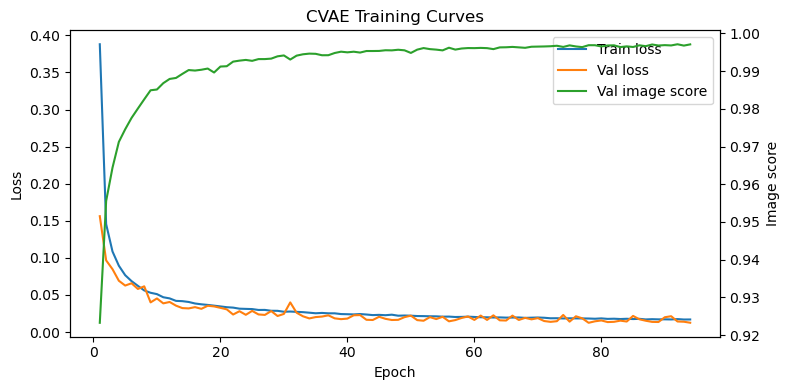

In [21]:
num_completed_epochs = min(len(train_losses), len(val_losses))
num_epochs = range(1, num_completed_epochs + 1)

if num_completed_epochs == 0:
    raise ValueError("No training history available to plot. Run train_loop with resume=False or load saved losses first.")

fig, ax_loss = plt.subplots(figsize=(8, 4))
ax_loss.plot(num_epochs, train_losses[:num_completed_epochs], label="Train loss")
ax_loss.plot(num_epochs, val_losses[:num_completed_epochs], label="Val loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")

if 'val_image_scores' in globals() and len(val_image_scores) >= num_completed_epochs:
    ax_score = ax_loss.twinx()
    ax_score.plot(num_epochs, val_image_scores[:num_completed_epochs], color="tab:green", label="Val image score")
    ax_score.set_ylabel("Image score")
    lines, labels = ax_loss.get_legend_handles_labels()
    score_lines, score_labels = ax_score.get_legend_handles_labels()
    ax_loss.legend(lines + score_lines, labels + score_labels, loc="best")
else:
    ax_loss.legend(loc="best")

plt.title("CVAE Training Curves")

plt.tight_layout()
plt.show()

### 10. Generate Counterfactuals

In [24]:
test(test_loader, model, device, img_size=img_size, lambda_outside=lambda_outside)

Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 1 completed. Total images processed: 16
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 2 completed. Total images processed: 32
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 3 completed. Total images processed: 48
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 4 completed. Total images processed: 64
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterf

### 10.1 Identify Original and Counterfactual Labels


In [27]:
LABEL_NAMES = {0: "healthy", 1: "pneumonia"}

def label_tensor_to_class_index(label):
    """Return class index from a scalar or one-hot label tensor."""
    label = torch.as_tensor(label).detach().cpu()
    if label.ndim == 0 or label.numel() == 1:
        return int(label.item())
    return int(torch.argmax(label).item())

def identify_counterfactual_labels(test_dataset, results_dir=project_root / "training-results" / "cvae" / "results"):
    """Map saved original/counterfactual images to labels from test_dataset.

    Original labels come directly from test_dataset. Counterfactual labels are the
    flipped target labels used in test(): healthy <-> pneumonia.
    """
    # if results_dir is None:
    #     results_dir = project_root / "training-results" / "cvae" / "results"

    results_dir = Path(results_dir)
    original_dir = results_dir / "original"
    counterfactual_dir = results_dir / "counterfactuals"

    rows = []
    for image_idx, label in enumerate(test_dataset.labels):
        original_class = label_tensor_to_class_index(label)
        counterfactual_class = 1 - original_class

        rows.append({
            "image_index": f"{image_idx:06d}",
            "original_image": str(original_dir / f"img_{image_idx:06d}_original.png"),
            "original_label_id": original_class,
            "original_label": LABEL_NAMES[original_class],
            "counterfactual_image": str(counterfactual_dir / f"img_{image_idx:06d}_counterfactual.png"),
            "counterfactual_label_id": counterfactual_class,
            "counterfactual_label": LABEL_NAMES[counterfactual_class],
        })

    labels_df = pd.DataFrame(rows)
    output_csv = results_dir / "counterfactual_labels.csv"
    labels_df.to_csv(output_csv, index=False)

    print(f"Saved labels for {len(labels_df)} original/counterfactual pairs to: {output_csv}")
    print("\nOriginal image label counts:")
    print(labels_df["original_label"].value_counts().to_string())
    print("\nCounterfactual image label counts:")
    print(labels_df["counterfactual_label"].value_counts().to_string())

    return labels_df

labels_df = identify_counterfactual_labels(test_dataset)

Saved labels for 9176 original/counterfactual pairs to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_labels.csv

Original image label counts:
original_label
healthy      8978
pneumonia     198

Counterfactual image label counts:
counterfactual_label
pneumonia    8978
healthy       198


In [28]:
heatmap_paths = save_cvae_change_heatmap_sweep(test_dataset, max_batches=3)

print(f"Saved {len(heatmap_paths)} heatmap files.")
print(f"First heatmap: {heatmap_paths[0]}")

Saving CVAE change heatmaps:   0%|          | 3/4489 [00:02<51:10,  1.46it/s]

Saved 3 CVAE change heatmap PNGs to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\change_heatmaps
Reused samples to fill fixed-size rows: 0 healthy, 8780 pneumonia
Saved 3 heatmap files.
First heatmap: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\change_heatmaps\cvae_change_heatmap_001.png


### 11. Evaluate

In [ ]:
DEFAULT_RESULTS_DIR = project_root / "training-results" / "cvae" / "results"

In [ ]:
original_dir = DEFAULT_RESULTS_DIR / "original"
counterfactual_dir = DEFAULT_RESULTS_DIR / "counterfactuals"
output_json = DEFAULT_RESULTS_DIR / "counterfactual_metrics.json"
output_csv = DEFAULT_RESULTS_DIR / "counterfactual_ssim.csv"
num_workers = 0
allow_download = False

In [ ]:
ssim_mean, ssim_std, ssim_min, ssim_max, ssim_rows = ssim_metric_calculation(device, output_csv, original_dir, counterfactual_dir)
fid, num_counterfactual_images, num_reference_images = fid_metric_calculation(original_dir, counterfactual_dir, device, batch_size, num_workers)

result = EvaluationResult(
    num_ssim_pairs=len(ssim_rows),
    ssim_mean=ssim_mean,
    ssim_std=ssim_std,
    ssim_min=ssim_min,
    ssim_max=ssim_max,
    num_counterfactual_images=num_counterfactual_images,
    num_reference_images=num_reference_images,
    fid=fid,
)
write_metrics_json(result, output_json)

print(json.dumps(asdict(result), indent=2))
print(f"\nSaved aggregate metrics to: {output_json}")
print(f"Saved per-image SSIM scores to: {output_csv}")

{
  "num_ssim_pairs": 9176,
  "ssim_mean": 0.9954542575084134,
  "ssim_std": 0.0017264750856280393,
  "ssim_min": 0.9398839473724365,
  "ssim_max": 0.9975956678390503,
  "num_counterfactual_images": 9176,
  "num_reference_images": 9176,
  "fid": 0.8587848544120789
}

Saved aggregate metrics to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_metrics.json
Saved per-image SSIM scores to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_ssim.csv
